<a href="https://colab.research.google.com/github/pawarashwajeet/pawarashwajeet/blob/main/Solver_for_2D_Heat_Diffusion_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Basic Imlementation


In [45]:
import numpy as np
import matplotlib.pyplot as plt


In [46]:
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

**Simulation input/parameters**

In [47]:
width, height = 10, 10      #plate size in length units (mm)
dx, dy = 0.1, 0.1           # uniform grid spacing in x- and y- directions
D = 4                       # thermal diffusivity of steel, 4 mm^2/sec
T_cold, T_hot = 300, 700
nx, ny = int(width/dx), int(height/dy)

dx2, dy2 = dx**2, dy**2
dt = dx2*dy2 / (2*D*(dx2+dy2))

**Initialize Temperature Distribution**

In [48]:
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()
# Initial conditions - circle of radius r centered at (cx, cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
  for j in range(ny):
    p2 = (i*dx-cx)**2 + (j*dy-cy)**2
    if p2 < r2:
      T0[i,j] = T_hot

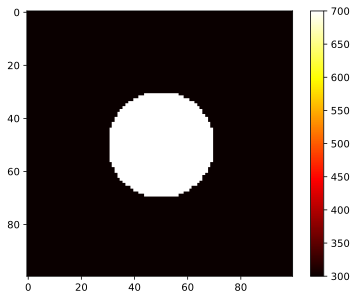

In [49]:
im = plt.imshow(T0, cmap=plt.get_cmap('hot'), vmin=T_cold, vmax=T_hot)
plt.colorbar(im)

**Time Step Update**

In [50]:
def advance_timestep(T0,T):
  #advance with Forward Difference in Time and central in space.
  for i in range(1,nx-1):
    for j in range(1,ny-1):
      Txx = (T0[i+1,j] - 2*T0[i,j] + T0[i-1,j])/dx2
      Tyy = (T0[i,j+1] - 2*T0[i,j] + T0[i,j-1])/dy2
      T[i,j] = T0[i,j] + D*dt*(Txx + Tyy)

      T0 = T.copy()
      return T0, T

**Perform Time Integration**

0 1
10 2
50 3
100 4


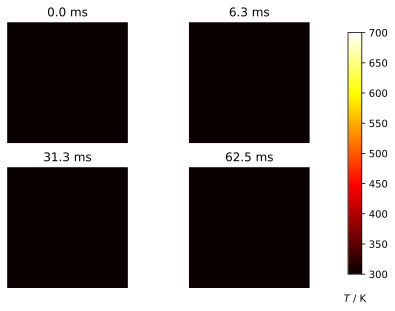

In [51]:
num_steps = 101      # number of timesteps
mfig = [0,10,50,100] # output figures at these timesteps
fignum = 0
fig = plt.figure()

for n in range(num_steps):
    T0, T = advance_timestep(T0,T)
    if n in mfig:
        fignum += 1
        print(n, fignum)
        ax = fig.add_subplot(220 + fignum)
        im = ax.imshow(T.copy(), cmap=plt.get_cmap('hot'), vmin=T_cold, vmax=T_hot)
        ax.set_axis_off()
        ax.set_title('{:.1f} ms'.format(n*dt*1000))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9,0.15,0.03,0.7])
cbar_ax.set_xlabel('$T$ / K', labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

** Profiling the basic (Python Loop) implementation**

In [52]:
import time

In [53]:
%%timeit
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()
# Initial conditions - circle of radius r centered at (cx, cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
  for j in range(ny):
    p2 = (i*dx-cx)**2 + (j*dy-cy)**2
    if p2 < r2:
      T0[i,j] = T_hot
for n in range(num_steps):
    T0, T = advance_timestep(T0,T)

4.25 ms ± 140 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [57]:
%%timeit
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()

# Initial conditions - circle of radius r centered at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
    for j in range(ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            T0[i,j] = T_hot

for n in range(num_steps):
    T0, T = advance_timestep(T0,T)

4.28 ms ± 99.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Vectorization using NumPy. Vectorization farm out these explicit loops to the much faster pre-compiled C-code underlying NumPy's array implementation.

In [54]:
def advance_timestep_vectorized(T0,T):
  #vectorization FTCS Implementation
  T[1:-1,1:-1] = T0[1:-1,1:-1] + D*dt*( (T0[2:,1:-1] - 2*T0[1:-1,1:-1] + T0[:-2,1:-1])/dx2
                                         + (T0[1:-1,2:] - 2*T0[1:-1,1:-1] + T0[1:-1,:-2])/dy2 )
  T0 = T.copy()
  return T0, T

0 1
10 2
50 3
100 4


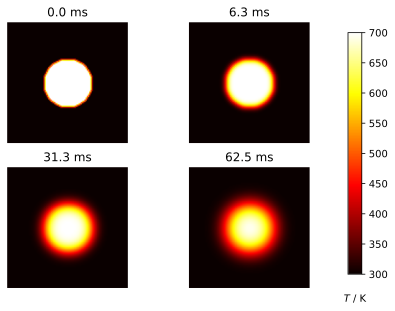

In [55]:
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()

# Initial conditions - circle of radius r centered at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
    for j in range(ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            T0[i,j] = T_hot

num_steps = 101      # number of timesteps
mfig = [0,10,50,100] # output figures at these timesteps
fignum = 0
fig = plt.figure()

for n in range(num_steps):
    T0, T = advance_timestep_vectorized(T0,T)
    if n in mfig:
        fignum += 1
        print(n, fignum)
        ax = fig.add_subplot(220 + fignum)
        im = ax.imshow(T.copy(), cmap=plt.get_cmap('hot'), vmin=T_cold, vmax=T_hot)
        ax.set_axis_off()
        ax.set_title('{:.1f} ms'.format(n*dt*1000))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9,0.15,0.03,0.7])
cbar_ax.set_xlabel('$T$ / K', labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

**Profiling the Vectorized Implementation**

In [ ]:
%%timeit



In [56]:
%%timeit
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()
# Initial conditions - circle of radius r centered at (cx, cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
  for j in range(ny):
    p2 = (i*dx-cx)**2 + (j*dy-cy)**2
    if p2 < r2:
      T0[i,j] = T_hot
for n in range(num_steps):
    T0, T = advance_timestep_vectorized(T0,T)

21.3 ms ± 1.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [58]:
%%timeit
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()

# Initial conditions - circle of radius r centered at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
    for j in range(ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            T0[i,j] = T_hot

for n in range(num_steps):
    T0, T = advance_timestep_vectorized(T0,T)

20 ms ± 1.86 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


**Further Optimization using JIT (Just In Time Compilation)**\
**JIT Compilation using NUMBA**

In [59]:
from numba import njit

In [ ]:
@njit


In [ ]:
@njit
def advance_timestep_optimized(T0,T):
    # advance with forward-difference in time, central difference in space
    for i in range(1,nx-1):
        for j in range(1,ny-1):
            Txx = (T0[i+1,j] - 2*T0[i,j] + T0[i-1,j]) / dx2
            Tyy = (T0[i,j+1] - 2*T0[i,j] + T0[i,j-1]) / dy2
            T[i,j] = T0[i,j] + D*dt*(Txx + Tyy)

    T0 = T.copy()
    return T0, T

0 1
10 2
50 3
100 4


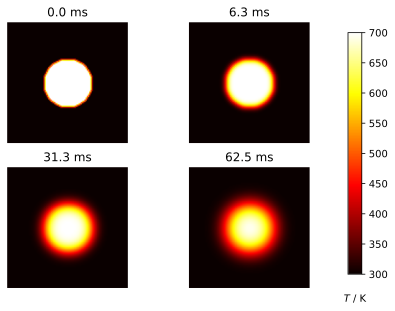

In [60]:
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()

# Initial conditions - circle of radius r centered at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
    for j in range(ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            T0[i,j] = T_hot

num_steps = 101      # number of timesteps
mfig = [0,10,50,100] # output figures at these timesteps
fignum = 0
fig = plt.figure()

for n in range(num_steps):
    T0, T = advance_timestep_vectorized(T0,T)
    if n in mfig:
        fignum += 1
        print(n, fignum)
        ax = fig.add_subplot(220 + fignum)
        im = ax.imshow(T.copy(), cmap=plt.get_cmap('hot'), vmin=T_cold, vmax=T_hot)
        ax.set_axis_off()
        ax.set_title('{:.1f} ms'.format(n*dt*1000))
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9,0.15,0.03,0.7])
cbar_ax.set_xlabel('$T$ / K', labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

**Profiling NUMBA implementation**

In [61]:
%%timeit
T0 = T_cold*np.ones((nx,ny))
T = T0.copy()

# Initial conditions - circle of radius r centered at (cx,cy) (mm)
r, cx, cy = 2, 5, 5
r2 = r**2

for i in range(nx):
    for j in range(ny):
        p2 = (i*dx-cx)**2 + (j*dy-cy)**2
        if p2 < r2:
            T0[i,j] = T_hot

for n in range(num_steps):
    T0, T = advance_timestep_vectorized(T0,T)

18.8 ms ± 2.39 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
